# Live Sensor Emotion Classification: Classical Models vs QSVM

This notebook evaluates calm vs stress classification using real sensor data collected from the MindTune prototype.

Data sources:
- HRM belt: heart rate and RR intervals
- Arduino Nano: DS18B20 temperature sensor and MPU6050 motion sensor

Models compared:
- Logistic Regression
- SVM
- Random Forest
- QSVM

Experiments include:
- preprocessing comparison
- encoding / feature map comparison
- entanglement comparison
- classical vs quantum performance comparison


# 1. Imports and Libraries

In [1]:
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# 2. Dataset Loading

In [2]:
DATA_DIR = "../data/live_sessions"

WINDOW_SIZE = 10   # 10 seconds
STEP_SIZE = 5      # overlap

RANDOM_STATE = 42

RAW_FEATURES = [
    "heart_rate",
    "rr_mean",
    "rmssd",
    "temperature",
    "movement_score"
]

In [3]:
files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("Files found:", len(files))
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df = pd.read_csv(file)
    df["session_id"] = os.path.basename(file).replace(".csv", "")
    dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

raw_df.head()

Files found: 10
calm_001.csv
calm_002.csv
calm_003.csv
calm_004.csv
calm_005.csv
stress_001.csv
stress_002.csv
stress_003.csv
stress_004.csv
stress_005.csv


,timestamp,heart_rate,rr_mean,rmssd,temperature,movement_score,sensor_state,label,session_id
0,2026-04-26T16:21:50,96,0.610352,NaN,30.25,0.078,neutral,calm,calm_001
1,2026-04-26T16:21:51,97,0.605794,0.004834,30.25,0.065,neutral,calm,calm_001
2,2026-04-26T16:21:52,98,0.603711,0.004502,30.25,0.067,neutral,calm,calm_001
3,2026-04-26T16:21:53,100,0.600307,0.006033,30.25,0.067,neutral,calm,calm_001
4,2026-04-26T16:21:54,101,0.595812,0.005621,30.25,0.059,neutral,calm,calm_001


In [4]:
print("Shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns)

print("\nLabels:")
print(raw_df["label"].value_counts())

print("\nMissing values:")
print(raw_df.isna().sum())

Shape: (1262, 9)

Columns:
Index(['timestamp', 'heart_rate', 'rr_mean', 'rmssd', 'temperature',
       'movement_score', 'sensor_state', 'label', 'session_id'],
      dtype='object')

Labels:
label
calm      647
stress    615
Name: count, dtype: int64

Missing values:
timestamp         0
heart_rate        0
rr_mean           0
rmssd             3
temperature       0
movement_score    0
sensor_state      0
label             0
session_id        0
dtype: int64


# 3. Data Cleaning and Preprocessing

In [5]:
df = raw_df.copy()

df["label"] = df["label"].str.lower().str.strip()

# Keep only calm and stress
df = df[df["label"].isin(["calm", "stress"])]

# Convert features to numeric
for col in RAW_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill RMSSD missing values with 0
df["rmssd"] = df["rmssd"].fillna(0)

# Drop rows missing essential sensor values
df = df.dropna(subset=["heart_rate", "rr_mean", "temperature", "movement_score", "label", "session_id"])

print("Clean shape:", df.shape)
print(df["label"].value_counts())

df.head()

Clean shape: (1262, 9)
label
calm      647
stress    615
Name: count, dtype: int64


,timestamp,heart_rate,rr_mean,rmssd,temperature,movement_score,sensor_state,label,session_id
0,2026-04-26T16:21:50,96,0.610352,0.000000,30.25,0.078,neutral,calm,calm_001
1,2026-04-26T16:21:51,97,0.605794,0.004834,30.25,0.065,neutral,calm,calm_001
2,2026-04-26T16:21:52,98,0.603711,0.004502,30.25,0.067,neutral,calm,calm_001
3,2026-04-26T16:21:53,100,0.600307,0.006033,30.25,0.067,neutral,calm,calm_001
4,2026-04-26T16:21:54,101,0.595812,0.005621,30.25,0.059,neutral,calm,calm_001


# 4. Exploratory Data Analysis

<Figure size 700x500 with 0 Axes>

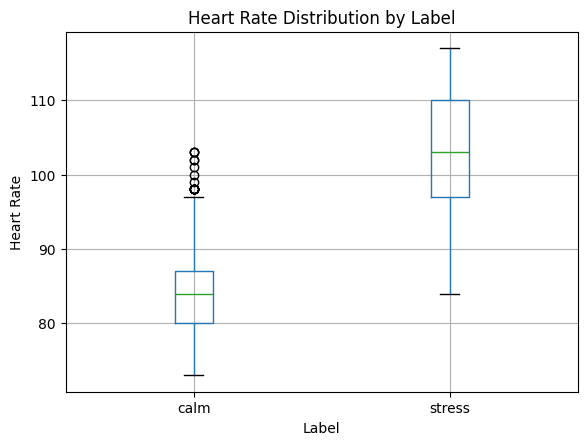

In [6]:
plt.figure(figsize=(7, 5))
df.boxplot(column="heart_rate", by="label")
plt.title("Heart Rate Distribution by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Heart Rate")
plt.show()

<Figure size 700x500 with 0 Axes>

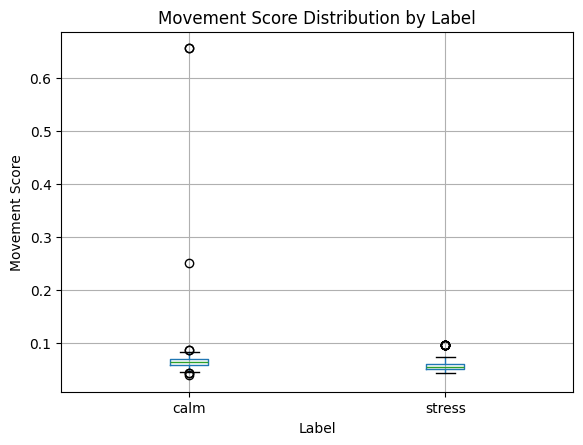

In [7]:
plt.figure(figsize=(7, 5))
df.boxplot(column="movement_score", by="label")
plt.title("Movement Score Distribution by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Movement Score")
plt.show()

<Figure size 700x500 with 0 Axes>

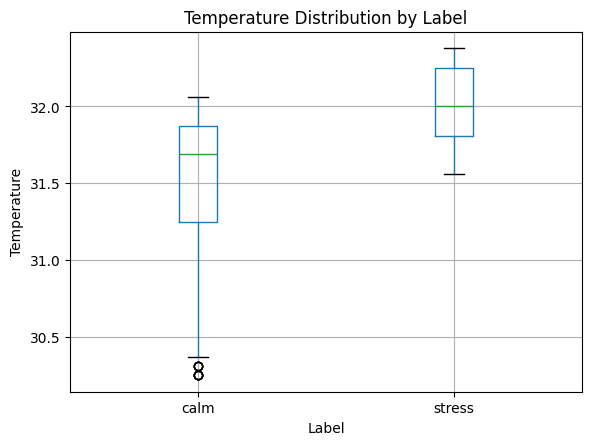

In [8]:
plt.figure(figsize=(7, 5))
df.boxplot(column="temperature", by="label")
plt.title("Temperature Distribution by Label")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("Temperature")
plt.show()

# 5. Window-Based Feature Extraction

In [9]:
def build_window_features(df, window_size=10, step=5):
    rows = []

    for session_id, session_df in df.groupby("session_id"):
        session_df = session_df.reset_index(drop=True)

        for start in range(0, len(session_df) - window_size + 1, step):
            window = session_df.iloc[start:start + window_size]

            label = window["label"].mode()[0]

            row = {
                "session_id": session_id,
                "label": label,

                "hr_mean": window["heart_rate"].mean(),
                "hr_std": window["heart_rate"].std(),
                "hr_min": window["heart_rate"].min(),
                "hr_max": window["heart_rate"].max(),
                "hr_range": window["heart_rate"].max() - window["heart_rate"].min(),

                "rr_mean_mean": window["rr_mean"].mean(),
                "rr_mean_std": window["rr_mean"].std(),

                "rmssd_mean": window["rmssd"].mean(),
                "rmssd_std": window["rmssd"].std(),

                "temp_mean": window["temperature"].mean(),
                "temp_std": window["temperature"].std(),

                "movement_mean": window["movement_score"].mean(),
                "movement_std": window["movement_score"].std(),
                "movement_max": window["movement_score"].max(),
            }

            rows.append(row)

    return pd.DataFrame(rows)

In [10]:
feature_df = build_window_features(df, window_size=10, step=5)

feature_df = feature_df.dropna().reset_index(drop=True)

print("Window dataset shape:", feature_df.shape)
print(feature_df["label"].value_counts())

feature_df.head()

Window dataset shape: (237, 16)
label
calm      122
stress    115
Name: count, dtype: int64


,session_id,label,hr_mean,hr_std,hr_min,hr_max,hr_range,rr_mean_mean,rr_mean_std,rmssd_mean,rmssd_std,temp_mean,temp_std,movement_mean,movement_std,movement_max
0,calm_001,calm,100.5,2.635231,96,103,7,0.594452,0.010182,0.004822,0.001782,30.286,0.041952,0.0656,0.007442,0.078
1,calm_001,calm,99.1,4.175324,92,103,11,0.585905,0.003080,0.005608,0.000468,30.374,0.061319,0.0640,0.009775,0.077
2,calm_001,calm,91.7,4.989990,84,99,15,0.594095,0.010042,0.006237,0.000717,30.433,0.022136,0.0650,0.009129,0.077
3,calm_001,calm,83.1,5.704774,76,91,15,0.625081,0.028952,0.007757,0.001344,30.470,0.042426,0.0630,0.006394,0.071
4,calm_001,calm,78.3,2.110819,76,83,7,0.677077,0.035292,0.009286,0.000801,30.518,0.040497,0.0606,0.005967,0.072


In [11]:
FEATURES = [
    "hr_mean",
    "hr_std",
    "hr_range",
    "rr_mean_mean",
    "rmssd_mean",
    "temp_mean",
    "movement_mean",
    "movement_std",
]

X = feature_df[FEATURES]
y = feature_df["label"]
groups = feature_df["session_id"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("X shape:", X.shape)

Classes: ['calm' 'stress']
X shape: (237, 8)


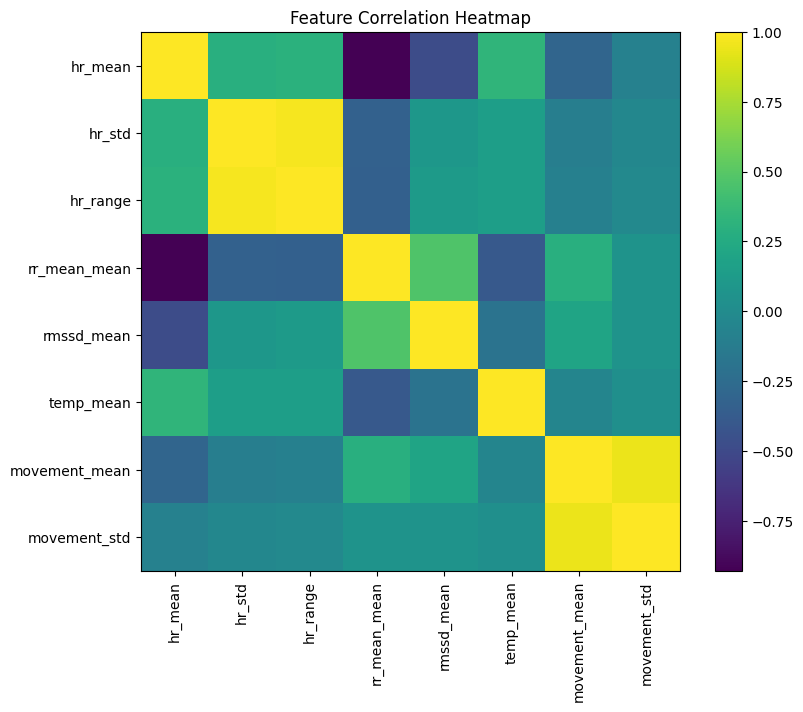

In [12]:
corr = feature_df[FEATURES].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(FEATURES)), FEATURES, rotation=90)
plt.yticks(range(len(FEATURES)), FEATURES)
plt.title("Feature Correlation Heatmap")
plt.show()

In [13]:
def evaluate_model(name, y_true, y_pred, train_time, test_time):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "train_time_sec": train_time,
        "test_time_sec": test_time,
    }

# 6. Classical Model Evaluation

In [14]:
preprocessors = {
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}

classical_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM RBF": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

classical_results = []

gkf = GroupKFold(n_splits=min(5, len(groups.unique())))

for prep_name, scaler in preprocessors.items():
    for model_name, model in classical_models.items():

        fold_results = []

        for train_idx, test_idx in gkf.split(X, y_encoded, groups):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

            pipe = Pipeline([
                ("scaler", scaler),
                ("model", model)
            ])

            start = time.time()
            pipe.fit(X_train, y_train)
            train_time = time.time() - start

            start = time.time()
            pred = pipe.predict(X_test)
            test_time = time.time() - start

            result = evaluate_model(
                f"{model_name} + {prep_name}",
                y_test,
                pred,
                train_time,
                test_time
            )
            fold_results.append(result)

        avg = pd.DataFrame(fold_results).mean(numeric_only=True).to_dict()
        avg["model"] = model_name
        avg["preprocessing"] = prep_name

        classical_results.append(avg)

classical_results_df = pd.DataFrame(classical_results)
classical_results_df.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,train_time_sec,test_time_sec,model,preprocessing
0,0.983333,0.6,0.600000,0.600000,0.005867,0.000799,Logistic Regression,standard
1,0.975333,0.6,0.600000,0.600000,0.002024,0.000880,SVM RBF,standard
2,0.971167,0.6,0.600000,0.600000,0.071898,0.004963,Random Forest,standard
4,0.963167,0.6,0.600000,0.600000,0.001227,0.000849,SVM RBF,minmax
5,0.971167,0.6,0.600000,0.600000,0.075465,0.005683,Random Forest,minmax
7,0.975500,0.6,0.600000,0.600000,0.003464,0.001399,SVM RBF,robust
6,0.987500,0.6,0.600000,0.600000,0.005593,0.001407,Logistic Regression,robust
8,0.971167,0.6,0.600000,0.600000,0.095409,0.006941,Random Forest,robust
3,0.936051,0.6,0.565217,0.581818,0.003189,0.000604,Logistic Regression,minmax


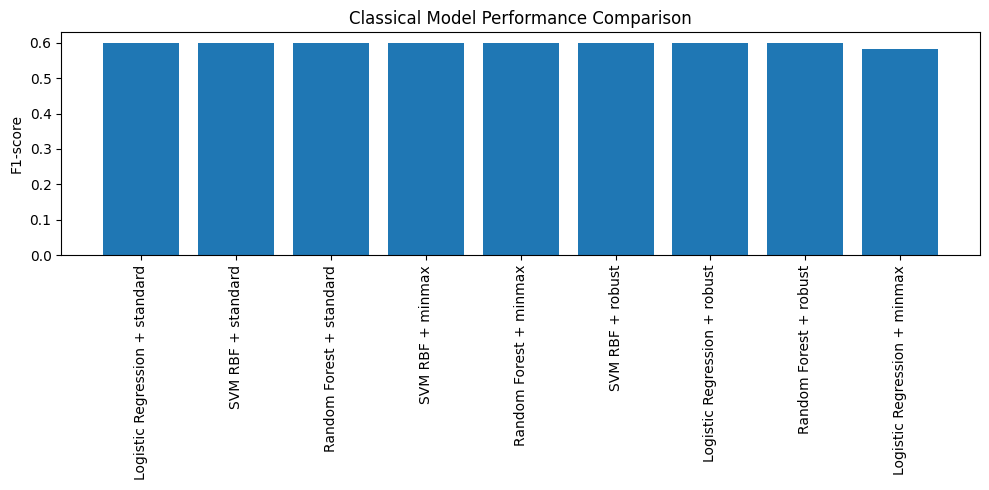

In [15]:
plot_df = classical_results_df.sort_values("f1", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"] + " + " + plot_df["preprocessing"], plot_df["f1"])
plt.xticks(rotation=90)
plt.ylabel("F1-score")
plt.title("Classical Model Performance Comparison")
plt.tight_layout()
plt.show()

# 7. Quantum SVM Evaluation


In [16]:
QSVM_FEATURES = FEATURES

X_q = feature_df[QSVM_FEATURES]
y_q = y_encoded
groups_q = groups

print("QSVM input shape:", X_q.shape)

QSVM input shape: (237, 8)


In [18]:
def run_qsvm_experiment(
    preprocessing_name,
    scaler,
    feature_map_name,
    entanglement,
    reps=1,
    pca_components=3
):
    fold_results = []

    gkf = GroupKFold(n_splits=min(5, len(groups_q.unique())))

    for train_idx, test_idx in gkf.split(X_q, y_q, groups_q):
        X_train, X_test = X_q.iloc[train_idx], X_q.iloc[test_idx]
        y_train, y_test = y_q[train_idx], y_q[test_idx]

        # Scale
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # PCA
        pca = PCA(n_components=pca_components, random_state=RANDOM_STATE)
        X_train_final = pca.fit_transform(X_train_scaled)
        X_test_final = pca.transform(X_test_scaled)

        feature_dim = X_train_final.shape[1]

        if feature_map_name == "zz":
            feature_map = ZZFeatureMap(
                feature_dimension=feature_dim,
                reps=reps,
                entanglement=entanglement
            )

        elif feature_map_name == "pauli_z":
            feature_map = PauliFeatureMap(
                feature_dimension=feature_dim,
                reps=reps,
                paulis=["Z"],
                entanglement=entanglement
            )

        elif feature_map_name == "pauli_zz":
            feature_map = PauliFeatureMap(
                feature_dimension=feature_dim,
                reps=reps,
                paulis=["Z", "ZZ"],
                entanglement=entanglement
            )

        else:
            raise ValueError("Unknown feature map")

        quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
        model = QSVC(quantum_kernel=quantum_kernel)

        start = time.time()
        model.fit(X_train_final, y_train)
        train_time = time.time() - start

        start = time.time()
        pred = model.predict(X_test_final)
        test_time = time.time() - start

        result = evaluate_model(
            "QSVM",
            y_test,
            pred,
            train_time,
            test_time
        )

        fold_results.append(result)

    avg = pd.DataFrame(fold_results).mean(numeric_only=True).to_dict()
    avg["model"] = "QSVM"
    avg["preprocessing"] = preprocessing_name
    avg["feature_map"] = feature_map_name
    avg["entanglement"] = entanglement
    avg["reps"] = reps
    avg["pca_components"] = pca_components

    return avg

In [19]:
qsvm_experiments = [
    ("standard", StandardScaler(), "zz", "linear"),
    ("minmax", MinMaxScaler(), "zz", "linear"),
    ("robust", RobustScaler(), "zz", "linear"),

    ("standard", StandardScaler(), "pauli_z", "linear"),
    ("standard", StandardScaler(), "pauli_zz", "linear"),

    ("standard", StandardScaler(), "zz", "full"),
    ("standard", StandardScaler(), "zz", "circular"),
]

qsvm_results = []

for exp in qsvm_experiments:
    preprocessing_name, scaler, feature_map_name, entanglement = exp

    print("\nRunning:", exp)

    result = run_qsvm_experiment(
        preprocessing_name=preprocessing_name,
        scaler=scaler,
        feature_map_name=feature_map_name,
        entanglement=entanglement,
        reps=1,
        pca_components=3
    )

    qsvm_results.append(result)

qsvm_results_df = pd.DataFrame(qsvm_results)
qsvm_results_df.sort_values("f1", ascending=False)


Running: ('standard', StandardScaler(), 'zz', 'linear')

Running: ('minmax', MinMaxScaler(), 'zz', 'linear')

Running: ('robust', RobustScaler(), 'zz', 'linear')

Running: ('standard', StandardScaler(), 'pauli_z', 'linear')

Running: ('standard', StandardScaler(), 'pauli_zz', 'linear')

Running: ('standard', StandardScaler(), 'zz', 'full')

Running: ('standard', StandardScaler(), 'zz', 'circular')


,accuracy,precision,recall,f1,train_time_sec,test_time_sec,model,preprocessing,feature_map,entanglement,reps,pca_components
1,0.954745,0.591667,0.600000,0.595745,47.005295,29.357957,QSVM,minmax,zz,linear,1,3
3,0.698658,0.590000,0.495652,0.538649,25.571064,12.861659,QSVM,standard,pauli_z,linear,1,3
5,0.746444,0.590909,0.495652,0.537886,34.779393,17.554455,QSVM,standard,zz,full,1,3
6,0.746444,0.590909,0.495652,0.537886,75.833902,39.395084,QSVM,standard,zz,circular,1,3
0,0.673718,0.551724,0.469565,0.497436,56.549272,25.113762,QSVM,standard,zz,linear,1,3
4,0.673718,0.551724,0.469565,0.497436,31.831311,15.925707,QSVM,standard,pauli_zz,linear,1,3
2,0.561342,0.522581,0.443478,0.468946,54.262336,30.223530,QSVM,robust,zz,linear,1,3


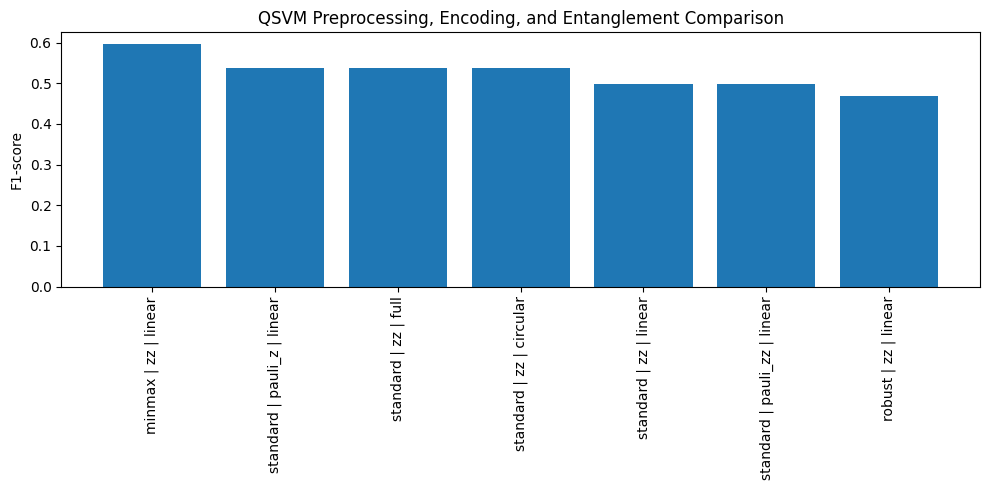

In [20]:
plot_df = qsvm_results_df.copy()
plot_df["experiment"] = (
    plot_df["preprocessing"]
    + " | "
    + plot_df["feature_map"]
    + " | "
    + plot_df["entanglement"]
)

plot_df = plot_df.sort_values("f1", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["experiment"], plot_df["f1"])
plt.xticks(rotation=90)
plt.ylabel("F1-score")
plt.title("QSVM Preprocessing, Encoding, and Entanglement Comparison")
plt.tight_layout()
plt.show()

# 8. Performance Comparison

In [21]:
classical_leaderboard = classical_results_df.copy()
classical_leaderboard["feature_map"] = "N/A"
classical_leaderboard["entanglement"] = "N/A"
classical_leaderboard["reps"] = "N/A"
classical_leaderboard["pca_components"] = "N/A"

qsvm_leaderboard = qsvm_results_df.copy()

leaderboard = pd.concat(
    [classical_leaderboard, qsvm_leaderboard],
    ignore_index=True
)

leaderboard = leaderboard.sort_values("f1", ascending=False)

leaderboard

,accuracy,precision,recall,f1,train_time_sec,test_time_sec,model,preprocessing,feature_map,entanglement,reps,pca_components
0,0.983333,0.600000,0.600000,0.600000,0.005867,0.000799,Logistic Regression,standard,N/A,N/A,N/A,N/A
1,0.975333,0.600000,0.600000,0.600000,0.002024,0.000880,SVM RBF,standard,N/A,N/A,N/A,N/A
2,0.971167,0.600000,0.600000,0.600000,0.071898,0.004963,Random Forest,standard,N/A,N/A,N/A,N/A
4,0.963167,0.600000,0.600000,0.600000,0.001227,0.000849,SVM RBF,minmax,N/A,N/A,N/A,N/A
6,0.987500,0.600000,0.600000,0.600000,0.005593,0.001407,Logistic Regression,robust,N/A,N/A,N/A,N/A
5,0.971167,0.600000,0.600000,0.600000,0.075465,0.005683,Random Forest,minmax,N/A,N/A,N/A,N/A
7,0.975500,0.600000,0.600000,0.600000,0.003464,0.001399,SVM RBF,robust,N/A,N/A,N/A,N/A
8,0.971167,0.600000,0.600000,0.600000,0.095409,0.006941,Random Forest,robust,N/A,N/A,N/A,N/A
10,0.954745,0.591667,0.600000,0.595745,47.005295,29.357957,QSVM,minmax,zz,linear,1,3
3,0.936051,0.600000,0.565217,0.581818,0.003189,0.000604,Logistic Regression,minmax,N/A,N/A,N/A,N/A


In [22]:
OUTPUT_PATH = "../results/live_sensor_model_comparison_results.csv"

leaderboard.to_csv(OUTPUT_PATH, index=False)

print("Saved results to:", OUTPUT_PATH)

Saved results to: ../results/live_sensor_model_comparison_results.csv


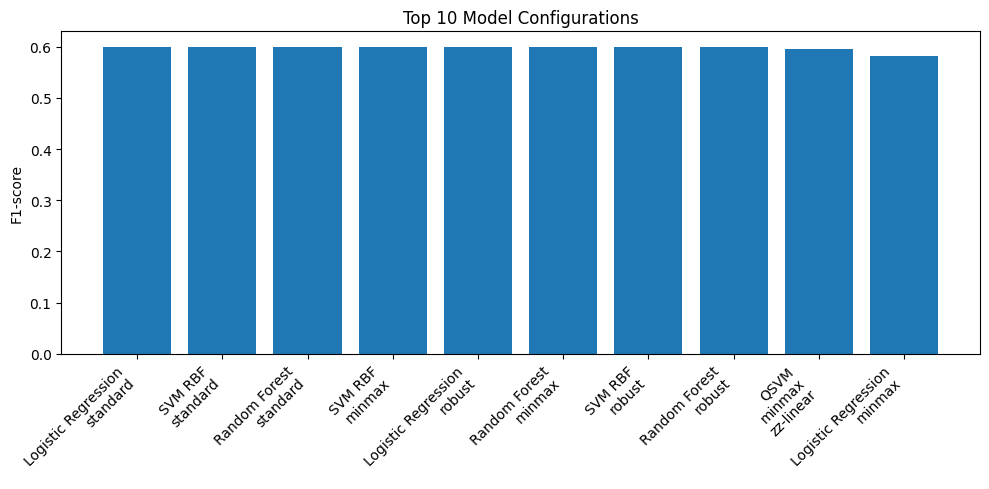

In [23]:
top_df = leaderboard.head(10).copy()

labels = []

for _, row in top_df.iterrows():
    if row["model"] == "QSVM":
        labels.append(f"QSVM\n{row['preprocessing']}\n{row['feature_map']}-{row['entanglement']}")
    else:
        labels.append(f"{row['model']}\n{row['preprocessing']}")

plt.figure(figsize=(10, 5))
plt.bar(labels, top_df["f1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Top 10 Model Configurations")
plt.tight_layout()
plt.show()

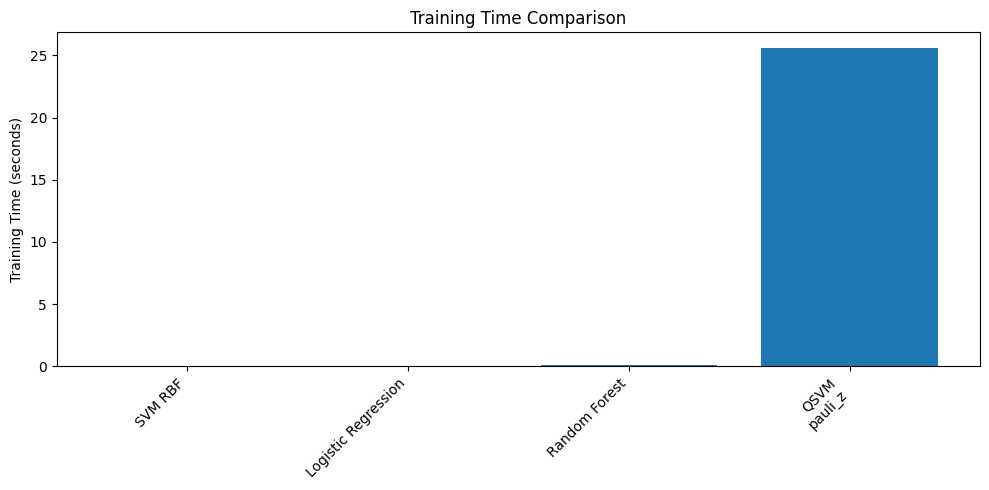

In [24]:
time_df = leaderboard.sort_values("train_time_sec", ascending=True).head(10)

labels = []

for _, row in time_df.iterrows():
    if row["model"] == "QSVM":
        labels.append(f"QSVM\n{row['feature_map']}")
    else:
        labels.append(row["model"])

plt.figure(figsize=(10, 5))
plt.bar(labels, time_df["train_time_sec"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.tight_layout()
plt.show()

Best classical model: Logistic Regression
Best preprocessing: standard


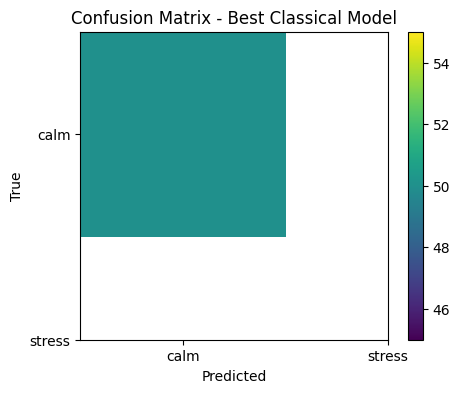

              precision    recall  f1-score   support

        calm       1.00      1.00      1.00        50
      stress       0.00      0.00      0.00         0

    accuracy                           1.00        50
   macro avg       0.50      0.50      0.50        50
weighted avg       1.00      1.00      1.00        50



In [26]:
best_classical = classical_results_df.sort_values("f1", ascending=False).iloc[0]

best_model_name = best_classical["model"]
best_prep_name = best_classical["preprocessing"]

print("Best classical model:", best_model_name)
print("Best preprocessing:", best_prep_name)

scaler = preprocessors[best_prep_name]
model = classical_models[best_model_name]

# Use first GroupKFold split for visualization
train_idx, test_idx = next(gkf.split(X, y_encoded, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

pipe = Pipeline([
    ("scaler", scaler),
    ("model", model)
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0, 1], encoder.classes_)
plt.yticks([0, 1], encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best Classical Model")
plt.show()

print(classification_report(
    y_test,
    pred,
    labels=[0,1],
    target_names=encoder.classes_,
    zero_division=0
))

## Interpretation

This experiment compares classical and quantum-enhanced approaches for binary emotion classification using real physiological and motion sensor data collected from MindTune.

The classical models provide a deployment-oriented baseline, while QSVM evaluates whether quantum feature spaces improve separability between calm and stress.

The evaluation uses GroupKFold by session ID to avoid data leakage between training and testing windows from the same recording session.

Key aspects tested:
- Different preprocessing techniques: StandardScaler, MinMaxScaler, RobustScaler
- Different quantum encodings: ZZFeatureMap, PauliFeatureMap
- Different entanglement structures: linear, full, circular
- Classical baselines: Logistic Regression, SVM, Random Forest

The best model should be selected based on F1-score and latency, not accuracy alone.


## Conclusion

The results show that live physiological sensor data can be used to distinguish calm and stress states. Classical models are expected to provide faster and more stable performance, while QSVM provides a research-oriented comparison for quantum-enhanced feature representation.

If QSVM achieves comparable performance but higher latency, this supports the design decision of using classical models for real-time deployment while keeping QSVM as a research component.

This aligns with MindTune’s architecture, where quantum-enhanced classification is evaluated experimentally, while the real-time prototype prioritizes responsiveness and usability.